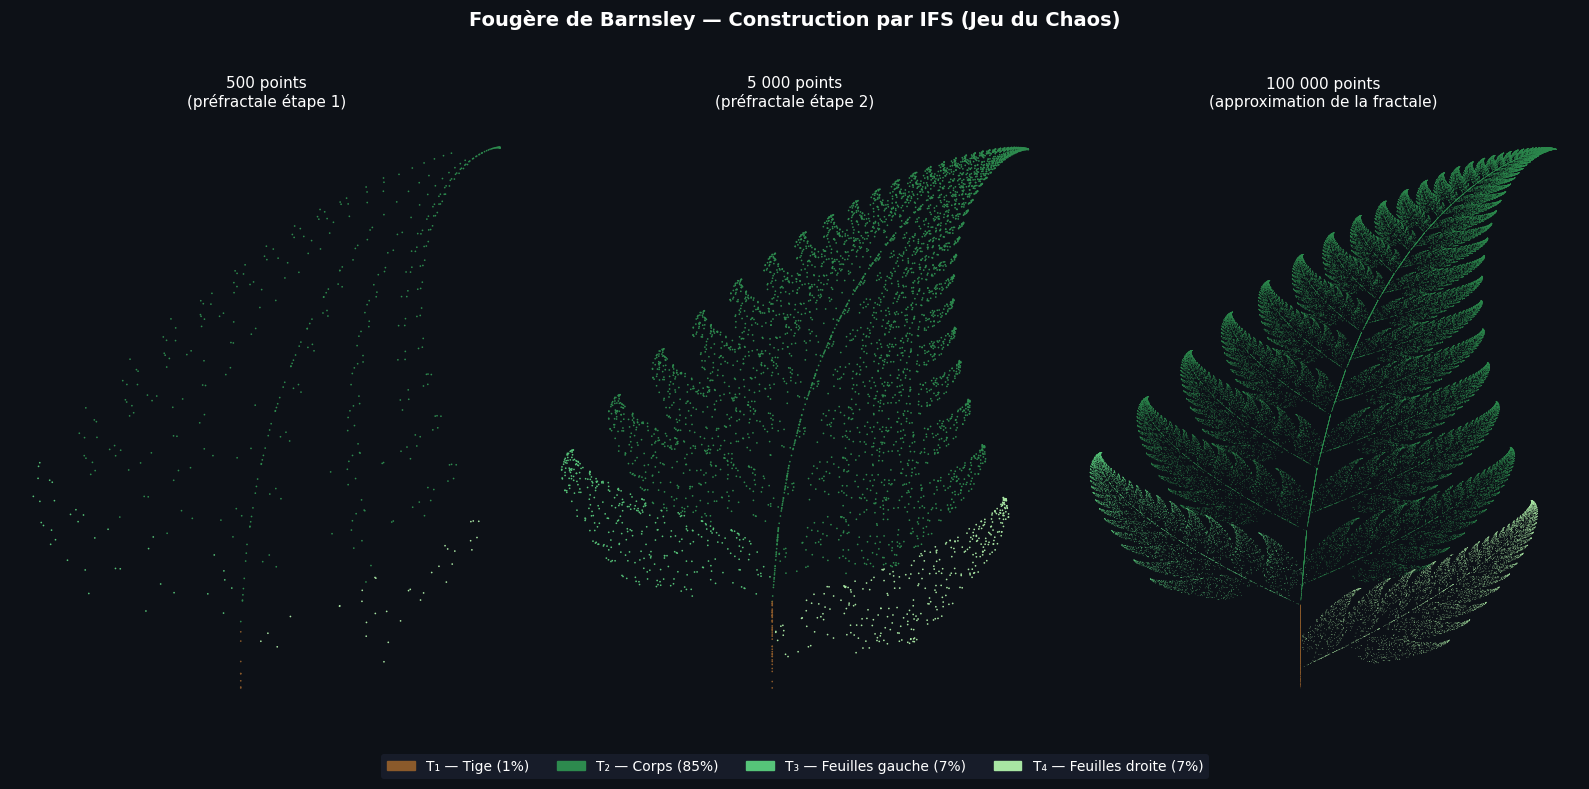

Image sauvegardée !


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def T1(x, y):
    """Tige centrale — probabilité 1%"""
    return 0, 0.16 * y

def T2(x, y):
    """Corps principal — probabilité 85%"""
    return 0.85*x + 0.04*y, -0.04*x + 0.85*y + 1.6

def T3(x, y):
    """Feuilles gauche — probabilité 7%"""
    return 0.20*x - 0.26*y, 0.23*x + 0.22*y + 1.6

def T4(x, y):
    """Feuilles droite — probabilité 7%"""
    return -0.15*x + 0.28*y, 0.26*x + 0.24*y + 0.44


def jeu_du_chaos(n_points=100000):

    fonctions = [T1, T2, T3, T4]
    proba     = [0.01, 0.85, 0.07, 0.07]

    x, y = 0.0, 0.0
    points_x = []
    points_y = []
    couleurs  = []

    palette = {0: '#8B5A2B', 1: '#2d8a4e', 2: '#56c479', 3: '#a8e6a3'}

    for _ in range(n_points):
        choix = np.random.choice([0, 1, 2, 3], p=proba)
        x, y  = fonctions[choix](x, y)
        points_x.append(x)
        points_y.append(y)
        couleurs.append(palette[choix])

    return points_x, points_y, couleurs



fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.patch.set_facecolor('#0d1117')

titres   = ['500 points\n(préfractale étape 1)',
            '5 000 points\n(préfractale étape 2)',
            '100 000 points\n(approximation de la fractale)']
n_points = [500, 5000, 100000]

for ax, n, titre in zip(axes, n_points, titres):
    px, py, cols = jeu_du_chaos(n)
    ax.scatter(px, py, c=cols, s=0.2 if n > 5000 else 1.5, linewidths=0)
    ax.set_facecolor('#0d1117')
    ax.set_title(titre, color='white', fontsize=11, pad=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

legendes = [
    mpatches.Patch(color='#8B5A2B', label='T₁ — Tige (1%)'),
    mpatches.Patch(color='#2d8a4e', label='T₂ — Corps (85%)'),
    mpatches.Patch(color='#56c479', label='T₃ — Feuilles gauche (7%)'),
    mpatches.Patch(color='#a8e6a3', label='T₄ — Feuilles droite (7%)'),
]
fig.legend(handles=legendes, loc='lower center', ncol=4,
           facecolor='#1a1f2e', edgecolor='none',
           labelcolor='white', fontsize=10, bbox_to_anchor=(0.5, 0.01))

fig.suptitle('Fougère de Barnsley — Construction par IFS (Jeu du Chaos)',
             color='white', fontsize=14, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])

plt.show()
print("Image sauvegardée !")
